# Phase 3 clean regime comparison

Single-purpose notebook.

Compares restored Phase 2 final QRC, Phase 3 RF-QRC ring, and ESN on the same date intersection, using:

1. raw forecast diagnostics, and
2. the original Phase 2 forecast-aware regime layer.


In [1]:
from pathlib import Path
import os
import subprocess
import sys

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, mean_squared_error


def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for p in [cwd, *cwd.parents]:
        if (p / "scripts").exists() and (p / "src" / "qpitome_qrc").exists():
            return p
    raise FileNotFoundError(
        "Could not find repo root. Open this notebook from inside qpitome-qrc-volatility."
    )


ROOT = find_repo_root()
os.chdir(ROOT)

TABLE_DIR = ROOT / "results" / "tables"
FIG_DIR = ROOT / "results" / "figures"
DATA_PATH = ROOT / "data" / "processed" / "phase2_spy_vix_volatility.csv"

TABLE_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

print("Repo root:", ROOT)
print("Dataset:", DATA_PATH)


Repo root: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility
Dataset: /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/data/processed/phase2_spy_vix_volatility.csv


In [2]:
AUTO_RESTORE_OLD_EXPORTERS = True
AUTO_RUN_MISSING_OUTPUTS = True

def run_cmd(cmd, *, check=True):
    print("$", " ".join(str(x) for x in cmd))
    result = subprocess.run(
        [str(x) for x in cmd],
        cwd=ROOT,
        text=True,
        stdout=subprocess.PIPE,
        stderr=subprocess.STDOUT,
    )
    print(result.stdout)
    if check and result.returncode != 0:
        raise RuntimeError(f"Command failed with exit code {result.returncode}: {cmd}")
    return result

# Restore old Phase 2 exporters if the cleanup branch does not currently have them.
required_scripts = [
    ROOT / "scripts" / "export_final_qrc_predictions.py",
    ROOT / "scripts" / "export_esn_predictions.py",
]
if any(not p.exists() for p in required_scripts) and AUTO_RESTORE_OLD_EXPORTERS:
    run_cmd([
        "git", "checkout", "99b5bab", "--",
        "scripts/export_final_qrc_predictions.py",
        "scripts/export_esn_predictions.py",
    ])

if not DATA_PATH.exists():
    if not AUTO_RUN_MISSING_OUTPUTS:
        raise FileNotFoundError(DATA_PATH)
    run_cmd([sys.executable, "scripts/prepare_phase2_spy_vix_dataset.py"])

required_outputs = {
    "Phase 2 final QRC": (
        TABLE_DIR / "phase2_qrc_final_encoding_readout_predictions.csv",
        [sys.executable, "scripts/export_final_qrc_predictions.py"],
    ),
    "ESN reference": (
        TABLE_DIR / "phase2_esn_predictions.csv",
        [sys.executable, "scripts/export_esn_predictions.py"],
    ),
    "Phase 3 RF-QRC ring": (
        TABLE_DIR / "phase3_rf_qrc_tail_probe_predictions_level_rate.csv",
        [sys.executable, "scripts/run_phase3_rf_qrc_tail_probe.py", "--input-mode", "level_rate"],
    ),
}

for label, (path, cmd) in required_outputs.items():
    if not path.exists():
        if not AUTO_RUN_MISSING_OUTPUTS:
            raise FileNotFoundError(path)
        print(f"Missing {label} output; generating it.")
        run_cmd(cmd)

print("Required files exist:")
for label, (path, _) in required_outputs.items():
    print(f"  {label}: {path.exists()} -> {path.relative_to(ROOT)}")


Required files exist:
  Phase 2 final QRC: True -> results/tables/phase2_qrc_final_encoding_readout_predictions.csv
  ESN reference: True -> results/tables/phase2_esn_predictions.csv
  Phase 3 RF-QRC ring: True -> results/tables/phase3_rf_qrc_tail_probe_predictions_level_rate.csv


In [3]:
# Load dataset directly from CSV to avoid notebook working-directory/import-state problems.
df = pd.read_csv(DATA_PATH, parse_dates=["date"]).sort_values("date").reset_index(drop=True)
TARGET = "future_rv_20d"

def chronological_split_by_date(df):
    train = df[df["date"] <= "2014-12-31"].copy()
    val = df[(df["date"] >= "2015-01-01") & (df["date"] <= "2019-12-31")].copy()
    test = df[df["date"] >= "2020-01-01"].copy()
    if min(len(train), len(val), len(test)) == 0:
        raise ValueError("Date split produced an empty train/val/test split.")
    return train.reset_index(drop=True), val.reset_index(drop=True), test.reset_index(drop=True)

def make_stress_features(frame):
    out = frame.copy().reset_index(drop=True)
    out["date"] = pd.to_datetime(out["date"])
    out["spy_selloff_stress"] = -out["spy_log_return"]
    out["spy_oc_selloff_stress"] = -out["spy_log_oc_return"]
    out["drawdown_stress"] = (
        -out["spy_drawdown_20d"]
        if out["spy_drawdown_20d"].median() < 0
        else out["spy_drawdown_20d"]
    )
    out["volume_stress"] = out["spy_log_volume_change"].abs()
    out["vix_level_stress"] = out["vix_close"]
    out["vix_change_stress"] = out["vix_log_change"].clip(lower=0.0)
    out["vix_range_stress"] = out["vix_log_hl_range"]
    out["realized_vol_stress"] = out["rv_20d"]
    return out

train, val, test = chronological_split_by_date(df)
train = make_stress_features(train)
val = make_stress_features(val)
timeline = make_stress_features(test)

thresholds = {
    "q80": float(train[TARGET].quantile(0.80)),
    "q90": float(train[TARGET].quantile(0.90)),
    "q95": float(train[TARGET].quantile(0.95)),
}

for split in [train, val, timeline]:
    split["future_high_vol_event_q80"] = split[TARGET] > thresholds["q80"]
    split["future_extreme_vol_event_q90"] = split[TARGET] > thresholds["q90"]
    split["future_crisis_candidate_q95"] = split[TARGET] > thresholds["q95"]

def train_q(col, quantile):
    return float(train[col].quantile(quantile))

timeline["direction_tag"] = "neutral"
timeline.loc[timeline["spy_log_return"] >= train_q("spy_log_return", 0.70), "direction_tag"] = "rally"
timeline.loc[timeline["spy_log_return"] <= train_q("spy_log_return", 0.30), "direction_tag"] = "selloff"

flag_specs = {
    "flag_realized_vol": ("rv_20d", 0.80),
    "flag_vix_level": ("vix_close", 0.80),
    "flag_vix_range": ("vix_log_hl_range", 0.80),
    "flag_drawdown": ("drawdown_stress", 0.80),
    "flag_selloff": ("spy_selloff_stress", 0.80),
    "flag_volume": ("volume_stress", 0.80),
    "flag_vol_acceleration": ("rv_slope_5_20", 0.80),
}

for flag, (col, quantile) in flag_specs.items():
    timeline[flag] = timeline[col] > train_q(col, quantile)

print("Split sizes:", {"train": len(train), "val": len(val), "test_timeline": len(timeline)})
print("Thresholds:", thresholds)
print("Test event counts:", {
    "q80": int(timeline["future_high_vol_event_q80"].sum()),
    "q90": int(timeline["future_extreme_vol_event_q90"].sum()),
    "q95": int(timeline["future_crisis_candidate_q95"].sum()),
})


Split sizes: {'train': 5459, 'val': 1258, 'test_timeline': 1058}
Thresholds: {'q80': 0.2125594115019885, 'q90': 0.27372979993114094, 'q95': 0.32594437578877844}
Test event counts: {'q80': 265, 'q90': 130, 'q95': 51}


In [4]:
phase2_qrc = pd.read_csv(TABLE_DIR / "phase2_qrc_final_encoding_readout_predictions.csv")
phase2_qrc["date"] = pd.to_datetime(phase2_qrc["date"])

rf_qrc = pd.read_csv(TABLE_DIR / "phase3_rf_qrc_tail_probe_predictions_level_rate.csv")
rf_qrc["date"] = pd.to_datetime(rf_qrc["date"])
rf_qrc = rf_qrc[rf_qrc["split"].eq("test")].copy()

esn = pd.read_csv(TABLE_DIR / "phase2_esn_predictions.csv")
esn["date"] = pd.to_datetime(esn["date"])

rf_col = "rf_qrc_second_encode_ring_level_rate_pred"
qrc_col = "qrc_pred_future_rv_20d"
esn_col = "esn_pred_future_rv_20d"

common_dates = (
    set(phase2_qrc["date"])
    & set(rf_qrc["date"])
    & set(esn["date"])
    & set(timeline["date"])
)

phase2_qrc = phase2_qrc[phase2_qrc["date"].isin(common_dates)].copy()
rf_qrc = rf_qrc[rf_qrc["date"].isin(common_dates)].copy()
esn = esn[esn["date"].isin(common_dates)].copy()
timeline_common = timeline[timeline["date"].isin(common_dates)].copy()

print("Common evaluation dates:", len(common_dates))
print("Date range:", min(common_dates), "to", max(common_dates))


Common evaluation dates: 1019
Date range: 2020-02-28 00:00:00 to 2024-03-15 00:00:00


In [5]:
def repo_qlike(y_true, y_pred, eps=1e-12):
    target = np.maximum(np.asarray(y_true, dtype=float) ** 2, eps)
    pred = np.maximum(np.asarray(y_pred, dtype=float) ** 2, eps)
    return float(np.mean(np.log(pred) + target / pred))

def mz_metrics(y_true, y_pred):
    y = np.asarray(y_true, dtype=float)
    x = np.asarray(y_pred, dtype=float)
    mask = np.isfinite(y) & np.isfinite(x)
    y = y[mask]
    x = x[mask]
    X = np.column_stack([np.ones_like(x), x])
    alpha, beta = np.linalg.lstsq(X, y, rcond=None)[0]
    fitted = alpha + beta * x
    ss_res = np.sum((y - fitted) ** 2)
    ss_tot = np.sum((y - y.mean()) ** 2)
    return {
        "mz_alpha": float(alpha),
        "mz_beta": float(beta),
        "mz_r2": float(1.0 - ss_res / ss_tot) if ss_tot > 0 else np.nan,
    }

def raw_forecast_score(name, y, p):
    row = {
        "model": name,
        "rmse": float(np.sqrt(mean_squared_error(y, p))),
        "qlike": repo_qlike(y, p),
        "corr": float(np.corrcoef(y, p)[0, 1]),
        "actual_std": float(np.std(y)),
        "pred_std": float(np.std(p)),
        "q80_amplitude_f1": f1_score(y > thresholds["q80"], p > thresholds["q80"], zero_division=0),
        "q90_amplitude_f1": f1_score(y > thresholds["q90"], p > thresholds["q90"], zero_division=0),
        "q95_amplitude_f1": f1_score(y > thresholds["q95"], p > thresholds["q95"], zero_division=0),
        "top20_pred_actual_ratio": float(np.mean(np.sort(p)[-20:]) / np.mean(np.sort(y)[-20:])),
    }
    row.update(mz_metrics(y, p))
    return row

merged_raw = (
    timeline_common[["date", TARGET]]
    .merge(phase2_qrc[["date", qrc_col]], on="date", how="inner")
    .merge(rf_qrc[["date", rf_col]], on="date", how="inner")
    .merge(esn[["date", esn_col]], on="date", how="inner")
    .sort_values("date")
)

y = merged_raw[TARGET].to_numpy()

raw_comparison = pd.DataFrame([
    raw_forecast_score("Phase 2 final QRC", y, merged_raw[qrc_col].to_numpy()),
    raw_forecast_score("Phase 3 RF-QRC ring", y, merged_raw[rf_col].to_numpy()),
    raw_forecast_score("ESN reference", y, merged_raw[esn_col].to_numpy()),
])

raw_comparison.to_csv(TABLE_DIR / "phase3_clean_raw_forecast_comparison.csv", index=False)
raw_comparison


,model,rmse,qlike,corr,actual_std,pred_std,q80_amplitude_f1,q90_amplitude_f1,q95_amplitude_f1,top20_pred_actual_ratio,mz_alpha,mz_beta,mz_r2
0,Phase 2 final QRC,0.095082,-2.229724,0.434624,0.104783,0.054796,0.562500,0.132450,0.000000,0.430313,0.035765,0.831094,0.188898
1,Phase 3 RF-QRC ring,0.105438,-1.040723,0.666724,0.104783,0.067121,0.397436,0.358025,0.413793,0.542389,0.066446,1.040823,0.444521
2,ESN reference,0.071896,-2.504775,0.728883,0.104783,0.080431,0.672199,0.479638,0.575000,0.705398,0.011302,0.949564,0.531270


In [6]:
def build_forecast_regime_layer(forecast_table, pred_col, model_name):
    layer = timeline_common.merge(forecast_table, on="date", how="inner")
    layer["model"] = model_name
    layer["pred_future_rv_20d"] = layer[pred_col]

    layer["forecast_high_vol"] = layer["pred_future_rv_20d"] > thresholds["q80"]
    layer["forecast_extreme_vol"] = layer["pred_future_rv_20d"] > thresholds["q90"]
    layer["forecast_crisis_vol"] = layer["pred_future_rv_20d"] > thresholds["q95"]

    confirm_cols = [
        "flag_vix_level",
        "flag_vix_range",
        "flag_drawdown",
        "flag_selloff",
        "flag_volume",
    ]
    layer["confirm_score"] = layer[confirm_cols].sum(axis=1)

    layer["forecast_regime"] = "normal"

    layer.loc[
        layer["forecast_high_vol"] | (layer["confirm_score"] >= 2),
        "forecast_regime",
    ] = "watch"

    layer.loc[
        (layer["forecast_high_vol"] & (layer["confirm_score"] >= 1))
        | layer["forecast_extreme_vol"],
        "forecast_regime",
    ] = "warning"

    layer.loc[
        (
            layer["forecast_extreme_vol"]
            & (layer["confirm_score"] >= 2)
            & (
                layer["flag_drawdown"]
                | layer["flag_selloff"]
                | layer["flag_vix_level"]
            )
        )
        | (
            layer["forecast_high_vol"]
            & (layer["confirm_score"] >= 4)
            & (layer["flag_drawdown"] | layer["flag_vix_level"])
        ),
        "forecast_regime",
    ] = "crisis_like"

    return layer.sort_values("date").reset_index(drop=True)

phase2_qrc_layer = build_forecast_regime_layer(phase2_qrc, qrc_col, "Phase 2 final QRC")
rf_qrc_layer = build_forecast_regime_layer(rf_qrc, rf_col, "Phase 3 RF-QRC ring")
esn_layer = build_forecast_regime_layer(esn, esn_col, "ESN reference")

regime_counts = pd.concat([
    phase2_qrc_layer.groupby(["model", "forecast_regime", "direction_tag"]).size().reset_index(name="n"),
    rf_qrc_layer.groupby(["model", "forecast_regime", "direction_tag"]).size().reset_index(name="n"),
    esn_layer.groupby(["model", "forecast_regime", "direction_tag"]).size().reset_index(name="n"),
], ignore_index=True)

regime_counts.to_csv(TABLE_DIR / "phase3_clean_regime_counts.csv", index=False)
regime_counts


,model,forecast_regime,direction_tag,n
0,Phase 2 final QRC,crisis_like,neutral,7
1,Phase 2 final QRC,crisis_like,rally,8
2,Phase 2 final QRC,crisis_like,selloff,43
3,Phase 2 final QRC,normal,neutral,284
4,Phase 2 final QRC,normal,rally,197
5,Phase 2 final QRC,normal,selloff,87
6,Phase 2 final QRC,warning,neutral,36
7,Phase 2 final QRC,warning,rally,90
8,Phase 2 final QRC,warning,selloff,62
9,Phase 2 final QRC,watch,neutral,23


In [7]:
def flag_metrics(signal, event):
    signal = signal.astype(bool).to_numpy()
    event = event.astype(bool).to_numpy()

    tp = int(np.sum(signal & event))
    fp = int(np.sum(signal & ~event))
    fn = int(np.sum(~signal & event))
    tn = int(np.sum(~signal & ~event))

    precision = tp / max(tp + fp, 1)
    recall = tp / max(tp + fn, 1)
    f1 = 2 * precision * recall / max(precision + recall, 1e-12)

    return {
        "tp": tp,
        "fp": fp,
        "fn": fn,
        "tn": tn,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "signal_rate": float(signal.mean()),
        "event_rate": float(event.mean()),
    }

def evaluate_regime_layer(layer):
    signal_defs = {
        "watch_or_higher": layer["forecast_regime"].isin(["watch", "warning", "crisis_like"]),
        "warning_or_higher": layer["forecast_regime"].isin(["warning", "crisis_like"]),
        "crisis_like": layer["forecast_regime"].eq("crisis_like"),
    }
    event_defs = {
        "future_high_vol_event_q80": layer["future_high_vol_event_q80"],
        "future_extreme_vol_event_q90": layer["future_extreme_vol_event_q90"],
        "future_crisis_candidate_q95": layer["future_crisis_candidate_q95"],
    }

    rows = []
    for signal_name, signal in signal_defs.items():
        for event_name, event in event_defs.items():
            row = {
                "model": layer["model"].iloc[0],
                "signal": signal_name,
                "event": event_name,
                "n": len(layer),
            }
            row.update(flag_metrics(signal, event))
            rows.append(row)
    return pd.DataFrame(rows)

regime_eval = pd.concat(
    [
        evaluate_regime_layer(phase2_qrc_layer),
        evaluate_regime_layer(rf_qrc_layer),
        evaluate_regime_layer(esn_layer),
    ],
    ignore_index=True,
)

main_regime_comparison = regime_eval[
    (
        (regime_eval["signal"] == "watch_or_higher")
        & (regime_eval["event"] == "future_high_vol_event_q80")
    )
    | (
        (regime_eval["signal"] == "warning_or_higher")
        & (regime_eval["event"] == "future_extreme_vol_event_q90")
    )
    | (
        (regime_eval["signal"] == "crisis_like")
        & (regime_eval["event"] == "future_crisis_candidate_q95")
    )
].sort_values(["event", "signal", "model"]).reset_index(drop=True)

regime_eval.to_csv(TABLE_DIR / "phase3_clean_full_regime_layer_evaluation.csv", index=False)
main_regime_comparison.to_csv(TABLE_DIR / "phase3_clean_main_regime_layer_comparison.csv", index=False)

main_regime_comparison


,model,signal,event,n,tp,fp,fn,tn,precision,recall,f1,signal_rate,event_rate
0,ESN reference,crisis_like,future_crisis_candidate_q95,1019,29,98,5,887,0.228346,0.852941,0.360248,0.124632,0.033366
1,Phase 2 final QRC,crisis_like,future_crisis_candidate_q95,1019,9,49,25,936,0.155172,0.264706,0.195652,0.056919,0.033366
2,Phase 3 RF-QRC ring,crisis_like,future_crisis_candidate_q95,1019,19,22,15,963,0.463415,0.558824,0.506667,0.040236,0.033366
3,ESN reference,warning_or_higher,future_extreme_vol_event_q90,1019,89,147,22,761,0.377119,0.801802,0.512968,0.231600,0.108930
4,Phase 2 final QRC,warning_or_higher,future_extreme_vol_event_q90,1019,71,175,40,733,0.288618,0.639640,0.397759,0.241413,0.108930
5,Phase 3 RF-QRC ring,warning_or_higher,future_extreme_vol_event_q90,1019,42,26,69,882,0.617647,0.378378,0.469274,0.066732,0.108930
6,ESN reference,watch_or_higher,future_high_vol_event_q80,1019,193,208,51,567,0.481297,0.790984,0.598450,0.393523,0.239450
7,Phase 2 final QRC,watch_or_higher,future_high_vol_event_q80,1019,202,249,42,526,0.447894,0.827869,0.581295,0.442591,0.239450
8,Phase 3 RF-QRC ring,watch_or_higher,future_high_vol_event_q80,1019,188,201,56,574,0.483290,0.770492,0.593997,0.381747,0.239450


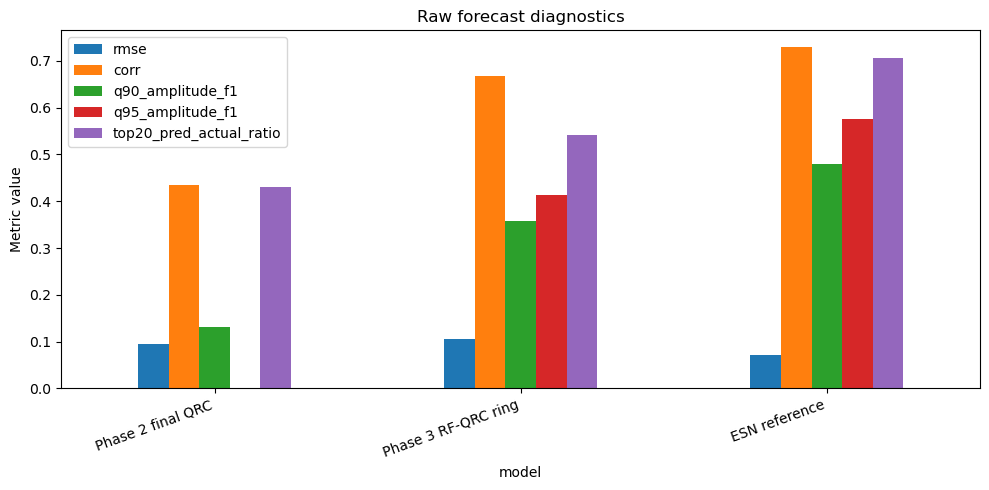

In [8]:
plot_raw = raw_comparison[[
    "model",
    "rmse",
    "corr",
    "q90_amplitude_f1",
    "q95_amplitude_f1",
    "top20_pred_actual_ratio",
]].set_index("model")

ax = plot_raw.plot(kind="bar", figsize=(10, 5))
ax.set_title("Raw forecast diagnostics")
ax.set_ylabel("Metric value")
ax.legend(loc="best")
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase3_clean_raw_forecast_diagnostics.png", dpi=200)
plt.show()


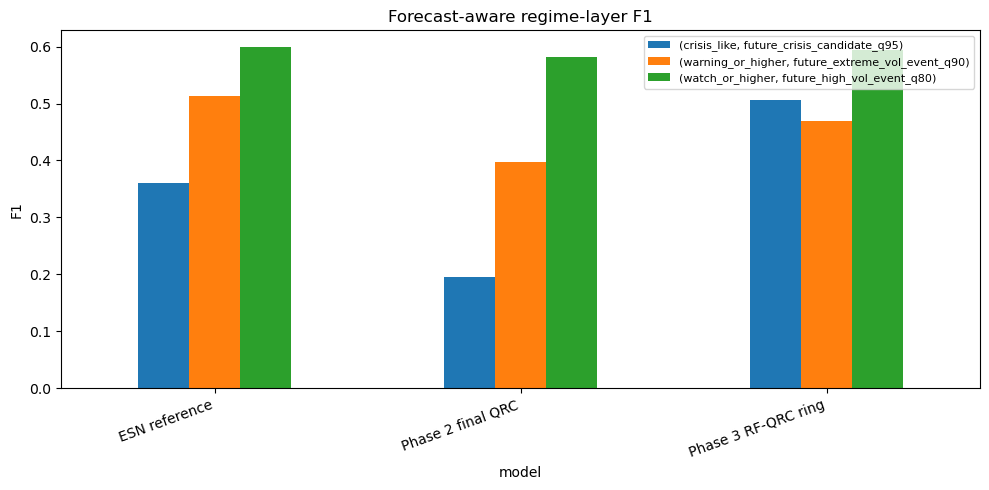

In [9]:
plot_regime = main_regime_comparison.pivot_table(
    index="model",
    columns=["signal", "event"],
    values="f1",
)

ax = plot_regime.plot(kind="bar", figsize=(10, 5))
ax.set_title("Forecast-aware regime-layer F1")
ax.set_ylabel("F1")
ax.legend(loc="best", fontsize=8)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.savefig(FIG_DIR / "phase3_clean_regime_layer_f1.png", dpi=200)
plt.show()


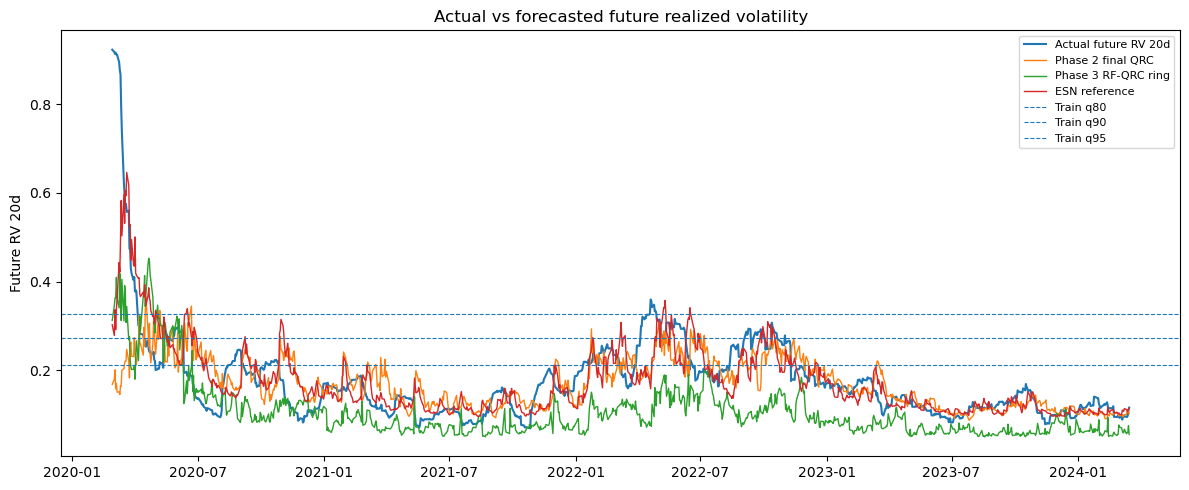

In [10]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.plot(merged_raw["date"], merged_raw[TARGET], label="Actual future RV 20d", linewidth=1.5)
ax.plot(merged_raw["date"], merged_raw[qrc_col], label="Phase 2 final QRC", linewidth=1.0)
ax.plot(merged_raw["date"], merged_raw[rf_col], label="Phase 3 RF-QRC ring", linewidth=1.0)
ax.plot(merged_raw["date"], merged_raw[esn_col], label="ESN reference", linewidth=1.0)

ax.axhline(thresholds["q80"], linestyle="--", linewidth=0.8, label="Train q80")
ax.axhline(thresholds["q90"], linestyle="--", linewidth=0.8, label="Train q90")
ax.axhline(thresholds["q95"], linestyle="--", linewidth=0.8, label="Train q95")

ax.set_title("Actual vs forecasted future realized volatility")
ax.set_ylabel("Future RV 20d")
ax.legend(loc="best", fontsize=8)
plt.tight_layout()
plt.savefig(FIG_DIR / "phase3_clean_actual_vs_forecasts.png", dpi=200)
plt.show()


In [11]:
print("Saved tables:")
for name in [
    "phase3_clean_raw_forecast_comparison.csv",
    "phase3_clean_regime_counts.csv",
    "phase3_clean_full_regime_layer_evaluation.csv",
    "phase3_clean_main_regime_layer_comparison.csv",
]:
    print(" ", TABLE_DIR / name)

print("\nSaved figures:")
for name in [
    "phase3_clean_raw_forecast_diagnostics.png",
    "phase3_clean_regime_layer_f1.png",
    "phase3_clean_actual_vs_forecasts.png",
]:
    print(" ", FIG_DIR / name)


Saved tables:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_raw_forecast_comparison.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_regime_counts.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_full_regime_layer_evaluation.csv
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/tables/phase3_clean_main_regime_layer_comparison.csv

Saved figures:
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Quantum Computing/GIC/qBraid/qpitome-qrc-volatility/results/figures/phase3_clean_raw_forecast_diagnostics.png
  /Users/claudia/Documents/Documents - Claudia’s MacBook Pro/Workspace/Qu